In [19]:
import pandas as pd

# -----------------------------
# 1. CARGAR DATOS
# -----------------------------
paper = pd.read_csv(r"G:/Mi unidad/Análisis_de_datos/La_escritura/FAOSTAT_data_es_5-4-2026 (1).csv")

# -----------------------------
# 2. FILTRAR PAPEL
# -----------------------------
paper = paper[paper['Producto'].str.contains('papel', case=False, na=False)]

# -----------------------------
# 3. LIMPIAR COLUMNAS
# -----------------------------
paper = paper[['Año', 'Valor']]
paper.columns = ['Año', 'Valor_en_toneladas']

# -----------------------------
# 4. AGRUPAR POR AÑO
# -----------------------------
paper = paper.groupby('Año')['Valor_en_toneladas'].sum().reset_index()

# -----------------------------
# 5. TRANSFORMAR A MILLONES
# -----------------------------
paper['Valor_en_millones'] = paper['Valor_en_toneladas'] / 1_000_000

# Redondear
paper['Valor_en_millones'] = paper['Valor_en_millones'].round(1)

# -----------------------------
# 6. RESULTADO
# -----------------------------
print("\nFAOSTAT LIMPIO:")
print(paper)

print("\nRango de años:")
print(paper['Año'].min(), "-", paper['Año'].max())

# -----------------------------
# 7. GUARDAR
# -----------------------------
paper.to_csv(r"G:/Mi unidad/Análisis_de_datos/La_escritura/papel_limpio.csv", index=False)

print("\n✔ Archivo papel_limpio.csv listo")


FAOSTAT LIMPIO:
     Año  Valor_en_toneladas  Valor_en_millones
0   2014            34758374               34.8
1   2015            33512561               33.5
2   2016            32395187               32.4
3   2017            31701619               31.7
4   2018            30395080               30.4
5   2019            27884194               27.9
6   2020            22707671               22.7
7   2021            24089696               24.1
8   2022            21342915               21.3
9   2023            15959115               16.0
10  2024            16416536               16.4

Rango de años:
2014 - 2024

✔ Archivo papel_limpio.csv listo


In [26]:
import pandas as pd

# -----------------------------
# 1. CARGAR CSV
# -----------------------------
internet = pd.read_csv(r"G:/Mi unidad/Análisis_de_datos/La_escritura/isoc_ci_ac_i$defaultview_linear.csv")

# -----------------------------
# 2. LIMPIAR
# -----------------------------
internet['TIME_PERIOD'] = pd.to_numeric(internet['TIME_PERIOD'], errors='coerce')
internet['OBS_VALUE'] = pd.to_numeric(internet['OBS_VALUE'], errors='coerce')

internet = internet.dropna(subset=['TIME_PERIOD', 'OBS_VALUE'])

# -----------------------------
# 3. FILTRAR INDICADOR (emails)
# -----------------------------
internet = internet[internet['indic_is'].str.contains('mail', case=False, na=False)]

# -----------------------------
# 4. FILTRAR SOLO "All individuals"
# -----------------------------
internet = internet[internet['ind_type'] == 'All individuals']

# -----------------------------
# 5. AGRUPAR → CREAR MEDIA UE
# -----------------------------
internet = internet.groupby('TIME_PERIOD')['OBS_VALUE'].mean().reset_index()

# -----------------------------
# 6. RENOMBRAR
# -----------------------------
internet.columns = ['Año', 'Internet']

# -----------------------------
# 7. FILTRAR AÑOS
# -----------------------------
internet = internet[(internet['Año'] >= 2014) & (internet['Año'] <= 2024)]

# -----------------------------
# 8. ORDENAR
# -----------------------------
internet = internet.sort_values('Año')

# -----------------------------
# 9. RESULTADO FINAL
# -----------------------------
print("\nEUROSTAT FINAL LIMPIO (MEDIA UE):")
print(internet)

# -----------------------------
# 10. GUARDAR
# -----------------------------
internet.to_csv(r"G:/Mi unidad/Análisis_de_datos/La_escritura/internet_limpio.csv", index=False)

print("\n✔ Archivo internet_limpio.csv listo")


EUROSTAT FINAL LIMPIO (MEDIA UE):
    Año   Internet
0  2016  76.029444
1  2017  75.161220
2  2018  72.448810
3  2019  73.545366
4  2020  73.861447
5  2021  76.525526
6  2022  77.843088
7  2023  78.674167
8  2024  77.337162

✔ Archivo internet_limpio.csv listo


In [27]:
import pandas as pd

# -----------------------------
# 1. CARGAR CSV
# -----------------------------
internet = pd.read_csv(r"G:/Mi unidad/Análisis_de_datos/La_escritura/internet_limpio.csv")

# -----------------------------
# 2. RENOMBRAR COLUMNAS
# -----------------------------
internet = internet.rename(columns={
    'Internet': 'porcentaje_personas_usan_internet'
})

# -----------------------------
# 3. RESULTADO
# -----------------------------
print("\nEUROSTAT RENOMBRADO:")
print(internet)

# -----------------------------
# 4. GUARDAR
# -----------------------------
internet.to_csv(r"G:/Mi unidad/Análisis_de_datos/La_escritura/internet_limpio.csv", index=False)

print("\n✔ Archivo actualizado")


EUROSTAT RENOMBRADO:
    Año  porcentaje_personas_usan_internet
0  2016                          76.029444
1  2017                          75.161220
2  2018                          72.448810
3  2019                          73.545366
4  2020                          73.861447
5  2021                          76.525526
6  2022                          77.843088
7  2023                          78.674167
8  2024                          77.337162

✔ Archivo actualizado


In [28]:
pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: C:\Users\lejob\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


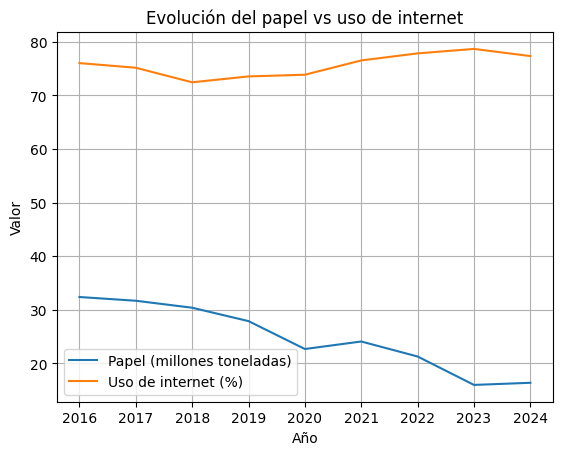

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
paper = pd.read_csv(r"G:/Mi unidad/Análisis_de_datos/La_escritura/papel_limpio.csv")
internet = pd.read_csv(r"G:/Mi unidad/Análisis_de_datos/La_escritura/internet_limpio.csv")

# Unir
df = pd.merge(paper, internet, on='Año')

# Gráfico
plt.figure()

plt.plot(df['Año'], df['Valor_en_millones'], label='Papel (millones toneladas)')
plt.plot(df['Año'], df['porcentaje_personas_usan_internet'], label='Uso de internet (%)')

plt.xlabel("Año")
plt.ylabel("Valor")
plt.title("Evolución del papel vs uso de internet")

plt.legend()
plt.grid()

plt.show()